In [1]:
# Importing necessary packages
from astroquery.utils.tap.core import TapPlus
import pandas as pd
import numpy as np
from astroquery.gaia import Gaia
import pyvo
import os, sys

from query_all import *

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


In [3]:
# Check which all servers are responding

ALL_SERVER().check_all_server()

✅GAIA Server is up and responding properly!
✅Successfully retrieved 1 row(s).


Pinging http://tapvizier.u-strasbg.fr/TAPVizieR/tap...
✅ VIZIER Server is UP and responding properly!
✅ Successfully retrieved 1 row(s).


Pinging https://gaia.ari.uni-heidelberg.de/tap...
✅ ARI (Heidelberg) Server is UP and responding properly!
✅ Successfully retrieved 1 row(s).


Pinging https://gaia.aip.de/tap...
✅ AIP (Potsdam) Server is UP and responding properly!
✅ Successfully retrieved 1 row(s).


In [4]:
df_data = fetch_gaia_data()
df_data.head()

,source_id,ra,dec,parallax,phot_g_mean_mag,bp_rp,teff_gspphot,logg_gspphot,mh_gspphot,pm,radial_velocity,lum_flame,radius_flame,mass_flame
0,3444412829062210560,85.138410,29.496849,0.639025,15.203718,1.460174,7350.752930,3.9354,-0.8404,5.390212,NaN,8.720807,1.847782,1.617188
1,6369569510812755328,307.080818,-75.549529,3.100123,18.305372,3.093098,NaN,NaN,NaN,24.347498,NaN,NaN,NaN,NaN
2,1130547237552438272,147.519438,76.265580,0.657031,16.076492,1.088842,4926.188965,4.4171,-0.1425,6.820306,NaN,0.643816,1.100034,NaN
3,2060421091813445504,303.558332,36.082737,0.887549,15.539901,1.361555,6545.811523,4.3074,-0.1009,6.871886,NaN,1.981810,1.094981,NaN
4,5535370966536274944,114.728808,-42.927278,1.003460,17.023443,1.655319,4467.231934,4.4363,-0.9888,4.227900,NaN,0.272274,0.877961,NaN


In [12]:
df_data["mag"] = df_data["phot_g_mean_mag"] + 5 + 5 * np.log10(df_data["parallax"] / 1000)

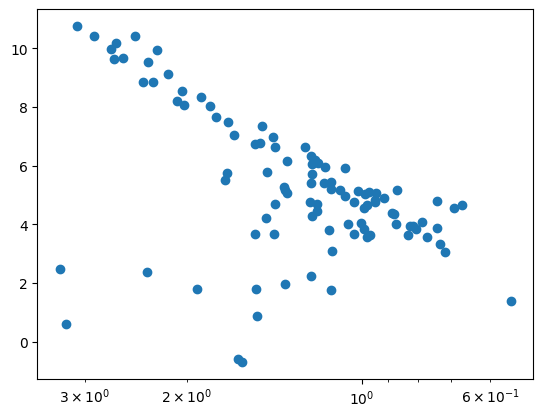

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

ax.xaxis.set_inverted(True)
ax.scatter(df_data["bp_rp"], df_data["mag"])
ax.set_xscale("log")
